# 🏢 Maven MegaMart – Retail Acquisition Analysis

## 📌 Executive Summary

This project analyzes 2M+ retail transactions (2016–2017) to evaluate a potential acquisition.

### Key Findings:
- 2017 sales outperformed 2016.
- Sales peak on Mondays and Tuesdays.
- Young single-parent households (19–24) are high-value customers.
- Lower-income households drive strong revenue contribution.
- Spirits is the top department among young consumers.

### Business Impact:
The retailer demonstrates stable growth and strong demographic alignment, supporting acquisition feasibility.

In [1]:
# 📂 Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')  # Improve visualization aesthetics

## 📂 Data Loading

In [22]:
# 📊 Load transactions dataset

path = "data/project_transactions/project_transactions.csv"
cols = ["household_key", "BASKET_ID", "DAY", "PRODUCT_ID", "QUANTITY", "SALES_VALUE"]
dtypes = {
    "DAY": "Int16",
    "QUANTITY": "Int32",
    "STORE_ID": "Int32",
    "PRODUCT_ID": "Int32"
}
# store the data into transaction dataframe
transactions = pd.read_csv(path, dtype=dtypes, usecols=cols)

transactions.head()  # Display the first few rows of the transactions dataset

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE
0,1364,26984896261,1,842930,1,2.19
1,1364,26984896261,1,897044,1,2.99
2,1364,26984896261,1,920955,1,3.09
3,1364,26984896261,1,937406,1,2.50
4,1364,26984896261,1,981760,1,0.60


## 🛠 Data Preparation
- Optimized data types
- Created Date column
- Prepared dataset for analysis

In [23]:
transactions = (
                    transactions.assign(date = (pd.to_datetime("2016", format='%Y') 
                                            + pd.to_timedelta(transactions["DAY"].sub(1).astype(str) + " days"))
                                        )
                    .drop(["DAY"], axis=1)
                )

transactions.head()

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,date
0,1364,26984896261,842930,1,2.19,2016-01-01
1,1364,26984896261,897044,1,2.99,2016-01-01
2,1364,26984896261,920955,1,3.09,2016-01-01
3,1364,26984896261,937406,1,2.50,2016-01-01
4,1364,26984896261,981760,1,0.60,2016-01-01


## 📊 Business KPI Snapshot

In [43]:
# Total Revenue
total_revenue = transactions["SALES_VALUE"].sum()

# Unique Customers
unique_customers = transactions["household_key"].nunique()

# Total Transactions
total_transactions = transactions["BASKET_ID"].nunique()

# Average Basket Value
avg_basket_value = (
    transactions.groupby("BASKET_ID")["SALES_VALUE"].sum().mean()
)

# Average Revenue per Customer
avg_revenue_per_customer = total_revenue / unique_customers

print("📊 Business KPIs")
print("----------------------------")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Unique Customers: {unique_customers}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Basket Value: ${avg_basket_value:,.2f}")
print(f"Avg Revenue per Customer: ${avg_revenue_per_customer:,.2f}")

📊 Business KPIs
----------------------------
Total Revenue: $6,666,243.50
Unique Customers: 2099
Total Transactions: 232939
Average Basket Value: $28.62
Avg Revenue per Customer: $3,175.91


## 📈 Sales Trend Analysis

### 📈 Year-over-Year Growth Analysis

In [42]:
monthly_sales = (
    transactions
    .set_index("date")
    .resample("M")["SALES_VALUE"]
    .sum()
    .to_frame()
)

monthly_sales["Year"] = monthly_sales.index.year
monthly_sales["Month"] = monthly_sales.index.month

pivot_sales = monthly_sales.pivot(
    index="Month",
    columns="Year",
    values="SALES_VALUE"
)

pivot_sales["YoY_Growth_%"] = (
    (pivot_sales[2017] - pivot_sales[2016]) 
    / pivot_sales[2016] * 100
)

pivot_sales

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\2636451724.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["SALES_VALUE"]


Year,2016,2017,YoY_Growth_%
Month,,,
1,46557.97,320301.20,587.962125
2,97315.16,298058.26,206.281426
3,185521.82,325511.23,75.457113
4,267801.38,308786.99,15.304481
5,298319.14,328829.68,10.227483
6,288952.45,304792.96,5.482047
7,296488.02,312853.52,5.519785
8,303951.35,341670.16,12.409489
9,302040.56,317498.59,5.117866


### 📈 Monthly Sales Plot

In [26]:
monthly_sales = transactions.set_index('date').loc[:, 'SALES_VALUE'].resample('M').sum().to_frame()
monthly_sales

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\3757218596.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = transactions.set_index('date').loc[:, 'SALES_VALUE'].resample('M').sum().to_frame()


,SALES_VALUE
date,
2016-01-31,46557.97
2016-02-29,97315.16
2016-03-31,185521.82
2016-04-30,267801.38
2016-05-31,298319.14
2016-06-30,288952.45
2016-07-31,296488.02
2016-08-31,303951.35
2016-09-30,302040.56


C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\3212423716.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  transactions.set_index('date').loc[:, 'SALES_VALUE'].resample('M').sum().plot()


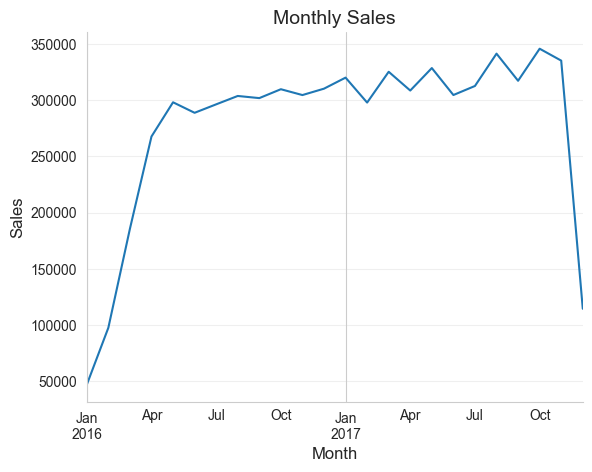

In [27]:
sns.set_style('whitegrid')  # Improve visualization aesthetics
transactions.set_index('date').loc[:, 'SALES_VALUE'].resample('M').sum().plot()

plt.title('Monthly Sales', size=14)
plt.xlabel('Month', size=12)
plt.ylabel('Sales', size=12)
plt.grid(alpha=0.3, axis='y')
sns.despine();

##### Observation: 

Due to the unusual pattern in the plot and the incomplete set of household observations, we will refine the analysis by filtering the dataset to provide a clearer trend.

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\447298963.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  transactions.set_index('date').sort_index().loc['2016-04':'2017-10', 'SALES_VALUE'].resample('M').sum().plot()


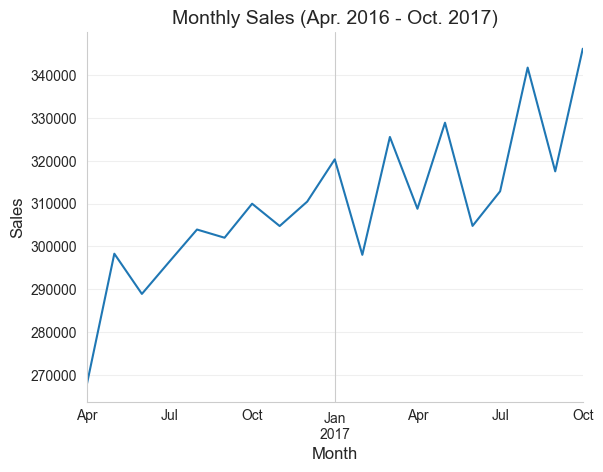

In [28]:
sns.set_style('whitegrid')  # Improve visualization aesthetics
transactions.set_index('date').sort_index().loc['2016-04':'2017-10', 'SALES_VALUE'].resample('M').sum().plot()

plt.title('Monthly Sales (Apr. 2016 - Oct. 2017)', size=14)
plt.xlabel('Month', size=12)
plt.ylabel('Sales', size=12)
plt.grid(alpha=0.3, axis='y')
sns.despine();

In [29]:
(transactions
 .set_index("date")
 .loc[:, ["SALES_VALUE"]]
 .resample("M")
 .sum()
 .assign(year_prior = lambda x: x["SALES_VALUE"].shift(12)) # create new column with 2016 monthly sales
 .loc['2017'])

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\2618131910.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,SALES_VALUE,year_prior
date,,
2017-01-31,320301.20,46557.97
2017-02-28,298058.26,97315.16
2017-03-31,325511.23,185521.82
2017-04-30,308786.99,267801.38
2017-05-31,328829.68,298319.14
2017-06-30,304792.96,288952.45
2017-07-31,312853.52,296488.02
2017-08-31,341670.16,303951.35
2017-09-30,317498.59,302040.56


#### Plot the sum of monthly sales for 2016 and 2017

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\4066421343.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


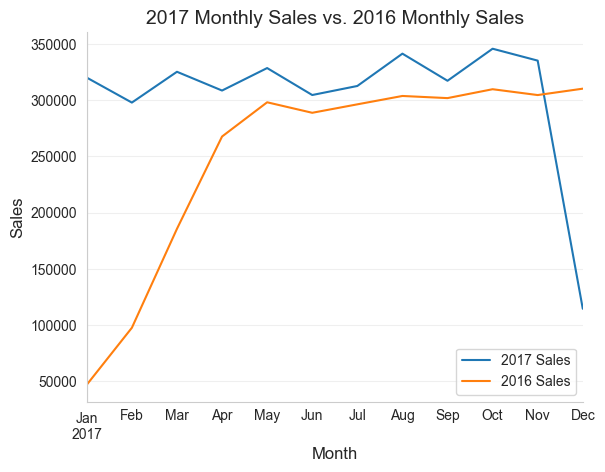

In [30]:
sns.set_style('whitegrid')  #Improve visualization aesthetics
(transactions
 .set_index("date")
 .loc[:, ["SALES_VALUE"]]
 .resample("M")
 .sum()
 .assign(year_prior = lambda x: x["SALES_VALUE"].shift(12))
 .loc['2017']).plot()

plt.title('2017 Monthly Sales vs. 2016 Monthly Sales', size=14)
plt.xlabel('Month', size=12)
plt.ylabel('Sales', size=12)
plt.legend(['2017 Sales', '2016 Sales'], loc='best')
plt.grid(alpha=0.3, axis='y')
sns.despine();

### Insight
Sales show steady growth from 2016 to 2017, with stronger seasonal peaks in 2017.

## Sales by Day of Week

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\2843496867.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_day.index, y=sales_by_day["SALES_VALUE"].values, palette='Blues')


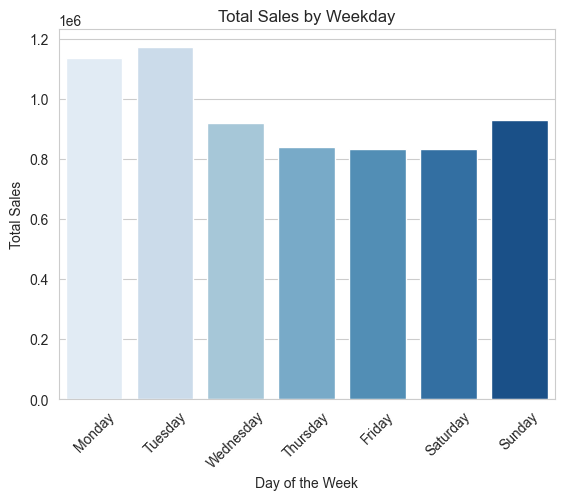

In [31]:
sales_by_day = (
    transactions.groupby(transactions["date"].dt.day_name())
    .agg({"SALES_VALUE": "sum"})
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])  # Ensure correct order
)

sns.barplot(x=sales_by_day.index, y=sales_by_day["SALES_VALUE"].values, palette='Blues')
plt.title('Total Sales by Weekday')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.show()

### Insight
Sales peak early in the week, suggesting structured household restocking behavior.

## 👥 Customer Segmentation Analysis

In [32]:
path = 'data/hh_demographic.csv'

dem_cols = ['AGE_DESC', 'INCOME_DESC', 'household_key', 'HH_COMP_DESC']

dem_dtypes = {"AGE_DESC": "category", "INCOME_DESC": "category", "HH_COMP_DESC":"category"}

demographics = pd.read_csv(path, usecols=dem_cols, dtype=dem_dtypes)

demographics.head()

,AGE_DESC,INCOME_DESC,HH_COMP_DESC,household_key
0,65+,35-49K,2 Adults No Kids,1
1,45-54,50-74K,2 Adults No Kids,7
2,25-34,25-34K,2 Adults Kids,8
3,25-34,75-99K,2 Adults Kids,13
4,45-54,50-74K,Single Female,16


In [34]:
household_sales = transactions.groupby('household_key').agg({'SALES_VALUE': 'sum'})

household_sales.head(10)

,SALES_VALUE
household_key,
1,4330.16
2,1954.34
3,2653.21
4,1200.11
5,779.06
6,5996.16
7,3400.05
8,5534.97
9,797.42


In [35]:
demographic_plus_household = demographics.merge(household_sales, on='household_key', how='inner')

demographic_plus_household

,AGE_DESC,INCOME_DESC,HH_COMP_DESC,household_key,SALES_VALUE
0,65+,35-49K,2 Adults No Kids,1,4330.16
1,45-54,50-74K,2 Adults No Kids,7,3400.05
2,25-34,25-34K,2 Adults Kids,8,5534.97
3,25-34,75-99K,2 Adults Kids,13,13190.92
4,45-54,50-74K,Single Female,16,1512.02
...,...,...,...,...,...
663,45-54,100-124K,Unknown,2087,7832.74
664,25-34,35-49K,Single Female,2088,4905.71
665,35-44,Under 15K,1 Adult Kids,2092,2290.54
666,45-54,50-74K,2 Adults No Kids,2094,3055.52


C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\2176805018.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_sum = demographic_plus_household.groupby('AGE_DESC', as_index=False)['SALES_VALUE'].sum()
C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\2176805018.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_sum['AGE_DESC'], y=sales_sum['SALES_VALUE'], data=sales_sum, palette='coolwarm', errorbar=None)


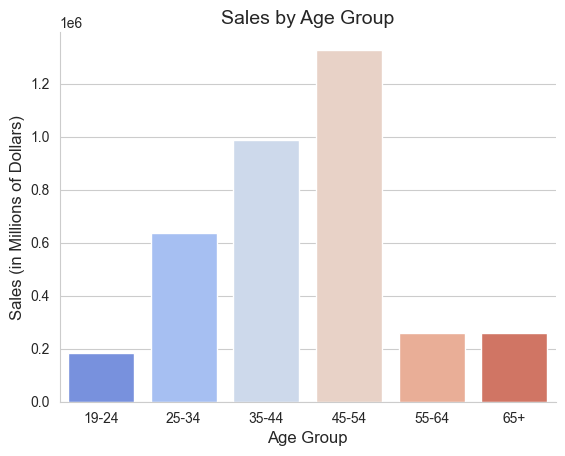

In [36]:
sns.set_style('whitegrid')  # Improve visualization aesthetics

# Aggregate sum of SALES_VALUE by AGE_DESC
sales_sum = demographic_plus_household.groupby('AGE_DESC', as_index=False)['SALES_VALUE'].sum()

# Plot using Seaborn
sns.barplot(x=sales_sum['AGE_DESC'], y=sales_sum['SALES_VALUE'], data=sales_sum, palette='coolwarm', errorbar=None)


plt.title('Sales by Age Group', size=14)
plt.ylabel('Sales (in Millions of Dollars)', size=12)
plt.xlabel('Age Group', size=12)
sns.despine()
plt.show();

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\89638805.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (demographic_plus_household.groupby('INCOME_DESC')['SALES_VALUE']
C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\89638805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=demographic_plus_household['INCOME_DESC'], y=demographic_plus_household["SALES_VALUE"], data=demographic_plus_household, palette='coolwarm',errorbar=None)


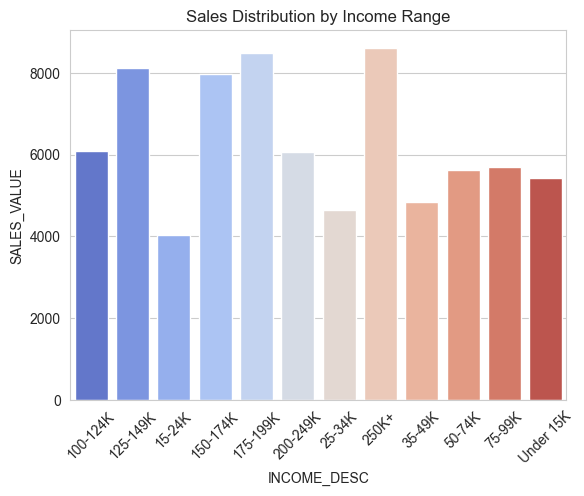

<Figure size 1000x600 with 0 Axes>

In [37]:
sns.set_style('whitegrid')  # Improve visualization aesthetics
(demographic_plus_household.groupby('INCOME_DESC')['SALES_VALUE']
                           .sum()
                           .sort_values(ascending=False))

sns.barplot(x=demographic_plus_household['INCOME_DESC'], y=demographic_plus_household["SALES_VALUE"], data=demographic_plus_household, palette='coolwarm',errorbar=None)
plt.title('Sales Distribution by Income Range')
plt.xticks(rotation=45)
plt.figure(figsize=(10,6))
plt.show()


In [38]:
# How many households in each age group and household composition combination

(demographic_plus_household.pivot_table(index='AGE_DESC', columns='HH_COMP_DESC', 
                                        values='SALES_VALUE', aggfunc='mean',
                                        margins=True)
                           .style.background_gradient(cmap="RdYlGn", axis=1)
)

C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\3865595884.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  (demographic_plus_household.pivot_table(index='AGE_DESC', columns='HH_COMP_DESC',


HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown,All
AGE_DESC,,,,,,,
19-24,7268.796667,5428.945000,4020.800000,4576.095556,3216.835000,4911.275000,4692.077692
25-34,5512.196875,5753.973514,5638.515833,4807.440588,4909.522381,7356.270000,5435.517521
35-44,6297.737778,6691.772264,6260.412444,6015.192069,4844.192000,4227.691818,6090.556728
45-54,6632.569167,6610.484490,5839.527027,4549.365405,4636.637083,4843.995682,5534.879958
55-64,3064.870000,4695.655000,5752.413684,4816.148462,3922.546250,7973.750000,5168.924200
65+,4040.810000,5536.866667,4614.108571,4059.699412,3871.556000,2879.290000,4340.936500
All,6032.802143,6280.069103,5599.857756,4895.928361,4544.646750,4936.127778,5468.398743


### Segmentation Summary
Young single-parent households and lower-income segments contribute disproportionately to total revenue, aligning with discount retail positioning.

## 🛒 Product Performance by Demographic

In [39]:
path = 'data/product.csv'

product_cols = ['PRODUCT_ID', 'DEPARTMENT',"COMMODITY_DESC"]

product_dtypes = {'PRODUCT_ID': 'Int32', 'DEPARTMENT': 'category',"COMMODITY_DESC":"category"}

products = pd.read_csv(path, usecols=product_cols, dtype=product_dtypes)

products.head()

,PRODUCT_ID,DEPARTMENT,COMMODITY_DESC
0,25671,GROCERY,FRZN ICE
1,26081,MISC. TRANS.,NO COMMODITY DESCRIPTION
2,26093,PASTRY,BREAD
3,26190,GROCERY,FRUIT - SHELF STABLE
4,26355,GROCERY,COOKIES/CONES


In [40]:
# Merge dataframes
combined_df = (
 transactions.merge(demographics, how='inner', left_on='household_key', right_on='household_key')
             .merge(products, how='inner', left_on='PRODUCT_ID', right_on='PRODUCT_ID')
              )

combined_df.head()

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,date,AGE_DESC,INCOME_DESC,HH_COMP_DESC,DEPARTMENT,COMMODITY_DESC
0,1364,26984896261,842930,1,2.19,2016-01-01,65+,100-124K,Single Female,GROCERY,CONVENIENT BRKFST/WHLSM SNACKS
1,1364,26984896261,897044,1,2.99,2016-01-01,65+,100-124K,Single Female,GROCERY,CRACKERS/MISC BKD FD
2,1364,26984896261,920955,1,3.09,2016-01-01,65+,100-124K,Single Female,MEAT,BEEF
3,1364,26984896261,937406,1,2.50,2016-01-01,65+,100-124K,Single Female,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES
4,1364,26984896261,981760,1,0.60,2016-01-01,65+,100-124K,Single Female,GROCERY,EGGS


In [41]:
(combined_df.pivot_table(index='DEPARTMENT', columns='AGE_DESC',
                        values='SALES_VALUE', aggfunc='sum')
           .style.background_gradient(cmap="RdYlGn", axis=1))


C:\Users\Manohar\AppData\Local\Temp\ipykernel_15160\2465654172.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  (combined_df.pivot_table(index='DEPARTMENT', columns='AGE_DESC',


AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
DEPARTMENT,,,,,,
,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AUTOMOTIVE,11.640000,21.250000,72.580000,55.920000,0.000000,16.370000
CHARITABLE CONT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CHEF SHOPPE,81.300000,134.160000,348.530000,418.240000,80.860000,149.240000
CNTRL/STORE SUP,2.000000,0.000000,1.000000,9.950000,2.000000,0.100000
COSMETICS,698.630000,2273.030000,4362.020000,5187.570000,986.260000,600.900000
COUP/STR & MFG,7.490000,48.420000,121.200000,154.550000,40.680000,20.490000
DAIRY DELI,3.800000,3.850000,7.390000,16.750000,3.140000,1.940000
DELI,4043.300000,18181.940000,34577.290000,44334.220000,9850.540000,10462.330000


### Key Insight
Young consumers show elevated spending in the Spirits department, indicating targeted marketing opportunities.

### EXPORT

Finally, export your pivot table to an excel file. Make sure to provide a sheet name.

In [ ]:
(combined_df.pivot_table(index="DEPARTMENT",
                            columns="AGE_DESC",
                            values="SALES_VALUE",
                            aggfunc="sum")
 .style.background_gradient(cmap="RdYlGn", axis=1)
 .to_excel("Output - demographic_category_sales.xlsx", sheet_name="sales_pivot")
)

## 🎯 Strategic Recommendations

### 1️⃣ Sales Optimization
- Introduce mid-week promotions (Wednesday–Friday) to improve lower-performing days.
- Maintain strong stock levels for peak days (Monday, Tuesday, Sunday).

### 2️⃣ Customer Targeting
- Focus marketing efforts on high-value segments such as young single-parent households.
- Align pricing strategies with lower-income customer segments.

### 3️⃣ Acquisition Outlook
- Consistent year-over-year growth and demographic alignment support acquisition feasibility.
- Product demand patterns suggest scalable revenue potential.

## 📌 Conclusion

The retailer demonstrates consistent revenue growth, strong demographic alignment, and clear product demand drivers. 
The data supports a favorable acquisition outlook.